# Comparing Healthy Places Index (HPI) and Opportunity Deserts

**Author: Lauren Vo**

**This notebook:**
- Loads tract-level opportunity metrics (our "desert" dataset)
- Loads TIGER 2023 Census tracts for California and filters to San Diego County
- Loads SANDAG's Health Places Index 3.0 shapefile
- Joins HPI scores to tracts and visualizes:
* HPI map
* Opportunity deserts map
* Scatterplot: HPI vs services per 1k youth, coloring desert vs non-desert

Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts
tract_metrics shape: (912, 28)
All CA tracts: (9129, 14)
San Diego tracts: (737, 14)
Merged sd_tracts_deserts: (912, 41)
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME_x', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'NAME_y', 'pop_total', 'youth_5_17', 'youth_10_19', 'youth_5_17_per_1k', 'youth_10_19_per_1k', 'median_hh_income_2023usd', 'households_total', 'households_zero_veh', 'zero_veh_share', 'services_total', 'library_count', 'ymca_count', 'rec_center_count', 'youth_org_count', 'stops_in_tract', 'stops_within_500m_per_tract', 'stops_within_500m_of_services', 'services_within_0_6mi', 'avg_distance_to_nearest_service_km', 'distance_to_nearest_library_km', 'distance_to_nearest_rec_center_km', 'distance_to_nearest_ymca_km', 'services_per_1k_youth_10_19', 'services_per_1k_youth_5_17', 'stops_within_500m_per_1k_youth', 'desert_flag']
HPI column

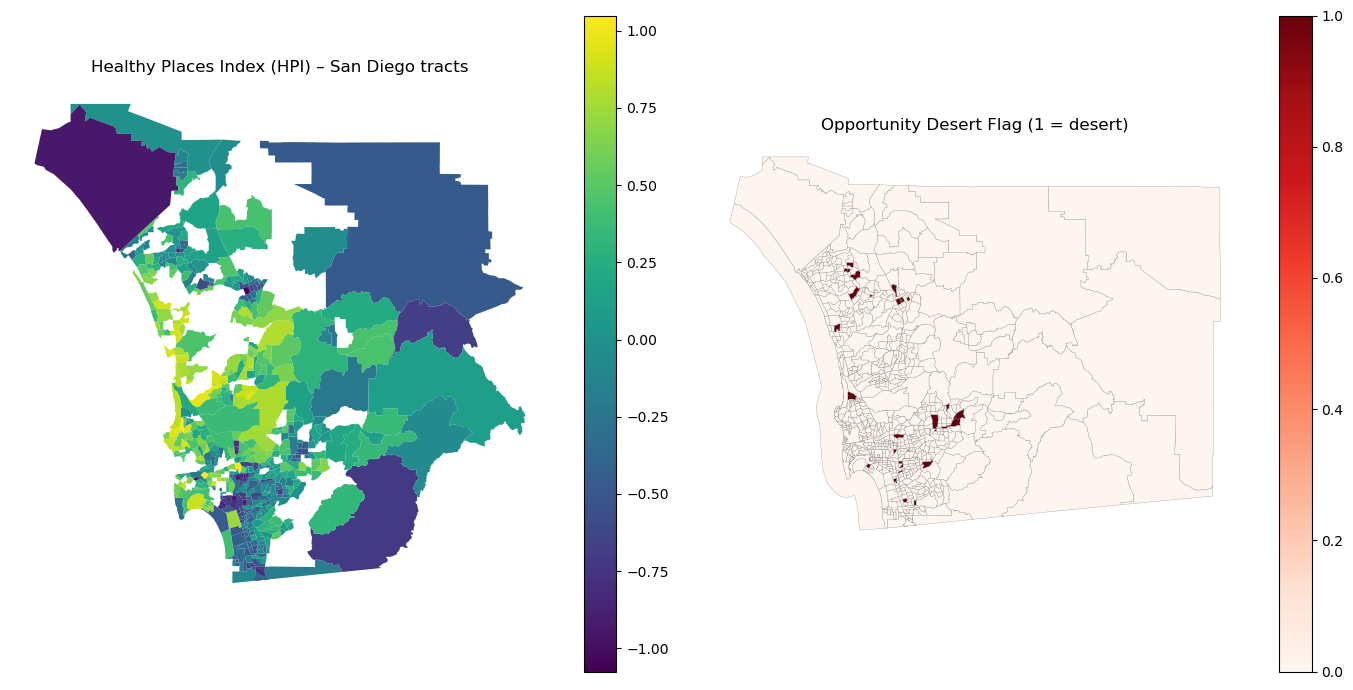

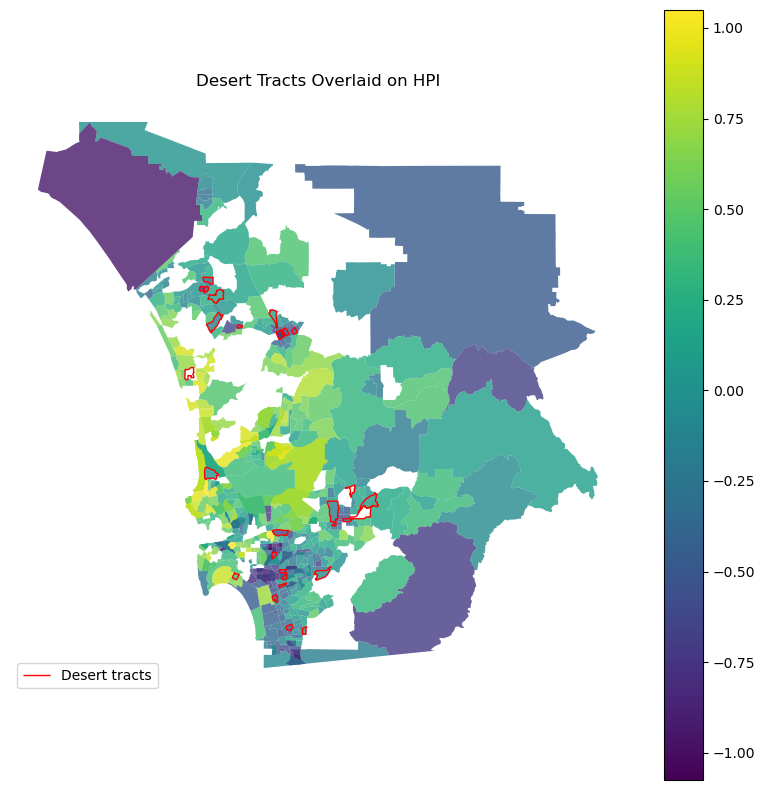

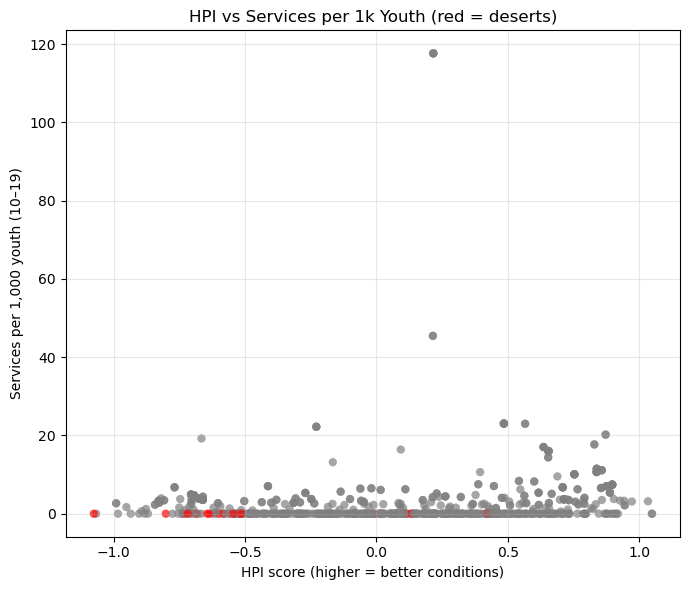

In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 150)

candidates = [Path("."), Path(".."), Path("../..")]

PROJECT_ROOT = None
for cand in candidates:
    if (cand / "data" / "raw" / "acs5" / "2023").exists():
        PROJECT_ROOT = cand.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/raw/acs5/2023 from this notebook location.")

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_SANDAG_DIR = DATA_DIR / "raw" / "sandag"
PROCESSED_ACS_2023_DIR = DATA_DIR / "processed" / "acs5" / "2023"
TIGER_2023_DIR = DATA_DIR / "external" / "tiger_tracts_2023"


# Load tract-level opportunity metrics (desert dataset) 
metrics_path = PROCESSED_ACS_2023_DIR / "tract_opportunity_desert_metrics_2023.csv"
tract_metrics = pd.read_csv(metrics_path, dtype={"GEOID": str})
print("tract_metrics shape:", tract_metrics.shape)
tract_metrics.head()

# Load TIGER 2023 tracts and subset to San Diego County (FIPS 073)
shp_path = TIGER_2023_DIR / "tl_2023_06_tract.shp"
zip_path = TIGER_2023_DIR / "tl_2023_06_tract.zip"

if shp_path.exists():
    tracts_gdf = gpd.read_file(shp_path)
elif zip_path.exists():
    tracts_gdf = gpd.read_file(f"zip://{zip_path}")
else:
    raise FileNotFoundError("Could not find tl_2023_06_tract.shp or tl_2023_06_tract.zip")

print("All CA tracts:", tracts_gdf.shape)

# Filter to San Diego County (COUNTYFP == '073')
sd_tracts = tracts_gdf[tracts_gdf["COUNTYFP"] == "073"].copy()
sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)
print("San Diego tracts:", sd_tracts.shape)

sd_tracts.head()

# Merge metrics onto tracts, make GeoDataFrame in WGS84 
tract_metrics["GEOID"] = tract_metrics["GEOID"].astype(str)

sd_tracts_deserts = sd_tracts.merge(tract_metrics, on="GEOID", how="left")
sd_tracts_deserts = sd_tracts_deserts.to_crs("EPSG:4326")

print("Merged sd_tracts_deserts:", sd_tracts_deserts.shape)
print(sd_tracts_deserts.columns.tolist())

cols = [c for c in ["GEOID", "NAME", "desert_flag"] if c in sd_tracts_deserts.columns]
sd_tracts_deserts[cols].head()

# Load Health Places Index 3.0 (HPI) shapefile from SANDAG
hpi_zip = RAW_SANDAG_DIR / "Health_Places_Index_3_0_shapefile.zip"
if not hpi_zip.exists():
    raise FileNotFoundError(hpi_zip)

hpi_gdf = gpd.read_file(f"zip://{hpi_zip}")
print("HPI columns:", hpi_gdf.columns.tolist())
hpi_gdf.head()

HPI_GEOID_COL = "geoid"   # tract ID
HPI_SCORE_COL = "hpi"     # overall HPI score


# Trim HPI to just GEOID + score, and harmonize GEOID to match metrics 
if HPI_GEOID_COL not in hpi_gdf.columns or HPI_SCORE_COL not in hpi_gdf.columns:
    raise KeyError(
        f"Check HPI_GEOID_COL ({HPI_GEOID_COL}) and HPI_SCORE_COL ({HPI_SCORE_COL}); "
        f"they are not in HPI columns: {hpi_gdf.columns.tolist()}"
    )

hpi_trim = hpi_gdf[[HPI_GEOID_COL, HPI_SCORE_COL]].copy()
hpi_trim = hpi_trim.rename(columns={HPI_GEOID_COL: "GEOID", HPI_SCORE_COL: "hpi_score"})
hpi_trim["GEOID"] = hpi_trim["GEOID"].astype(str)

print("HPI trimmed:", hpi_trim.shape)
hpi_trim.head()


# Join HPI onto San Diego tracts with our metrics
sd_tracts_deserts_hpi = sd_tracts_deserts.merge(hpi_trim, on="GEOID", how="left")
sd_tracts_deserts_hpi = sd_tracts_deserts_hpi.to_crs("EPSG:4326")

print("sd_tracts_deserts_hpi:", sd_tracts_deserts_hpi.shape)
sd_tracts_deserts_hpi[["GEOID", "hpi_score", "desert_flag"]].head()

 
# Map 1: side-by-side HPI vs Opportunity Deserts 

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: HPI choropleth
sd_tracts_deserts_hpi.plot(
    column="hpi_score",
    ax=axes[0],
    cmap="viridis",
    legend=True,
    edgecolor="none",
)
axes[0].set_title("Healthy Places Index (HPI) – San Diego tracts")
axes[0].set_axis_off()

# Right: desert_flag choropleth
sd_tracts_deserts_hpi.plot(
    column="desert_flag",
    ax=axes[1],
    cmap="Reds",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
)
axes[1].set_title("Opportunity Desert Flag (1 = desert)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


# Map 2: highlight deserts over HPI background 

fig, ax = plt.subplots(figsize=(8, 8))

# HPI as background
sd_tracts_deserts_hpi.plot(
    column="hpi_score",
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    alpha=0.8,
)

# Desert tracts on top in red outline
deserts = sd_tracts_deserts_hpi[sd_tracts_deserts_hpi["desert_flag"] == 1]
if not deserts.empty:
    deserts.boundary.plot(ax=ax, color="red", linewidth=1.0, label="Desert tracts")

ax.set_title("Desert Tracts Overlaid on HPI")
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

 
# Scatterplot: HPI vs services per 1k youth, colored by desert_flag 

fig, ax = plt.subplots(figsize=(7, 6))

valid = sd_tracts_deserts_hpi.dropna(subset=["hpi_score", "services_per_1k_youth_10_19"])
colors = valid["desert_flag"].map({0: "grey", 1: "red"})

ax.scatter(
    valid["hpi_score"],
    valid["services_per_1k_youth_10_19"],
    c=colors,
    alpha=0.7,
    edgecolor="none",
)

ax.set_xlabel("HPI score (higher = better conditions)")
ax.set_ylabel("Services per 1,000 youth (10–19)")
ax.set_title("HPI vs Services per 1k Youth (red = deserts)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Basic HPI distributions by desert_flag
sd_tracts_deserts_hpi["desert_flag"] = sd_tracts_deserts_hpi["desert_flag"].fillna(0).astype(int)

sd_tracts_deserts_hpi.groupby("desert_flag")["hpi_score"].describe()


,count,mean,std,min,25%,50%,75%,max
desert_flag,,,,,,,,
0,644.0,0.135213,0.502270,-1.066312,-0.247575,0.187785,0.562893,1.049520
1,25.0,-0.385802,0.366183,-1.075222,-0.634797,-0.521543,-0.083346,0.420151


In [39]:
# Bin HPI into quintiles (Very Low ... Very High)
quantiles = sd_tracts_deserts_hpi["hpi_score"].quantile([0.2, 0.4, 0.6, 0.8])

def hpi_bin(x):
    if pd.isna(x):
        return "No HPI"
    if x <= quantiles[0.2]:
        return "Very low"
    if x <= quantiles[0.4]:
        return "Low"
    if x <= quantiles[0.6]:
        return "Medium"
    if x <= quantiles[0.8]:
        return "High"
    return "Very high"

sd_tracts_deserts_hpi["hpi_bin"] = sd_tracts_deserts_hpi["hpi_score"].apply(hpi_bin)

# How many deserts in each HPI bin?
pd.crosstab(sd_tracts_deserts_hpi["hpi_bin"], sd_tracts_deserts_hpi["desert_flag"], normalize="columns")


desert_flag,0,1
hpi_bin,,
High,0.149321,0.035714
Low,0.147059,0.142857
Medium,0.145928,0.178571
No HPI,0.271493,0.107143
Very high,0.151584,0.000000
Very low,0.134615,0.535714


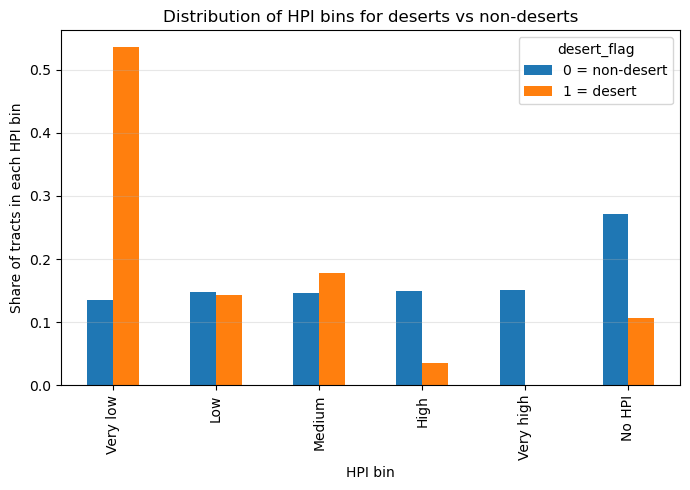

In [40]:
# Bar chart: share of tracts in each HPI bin, by desert flag

ct = pd.crosstab(
    sd_tracts_deserts_hpi["hpi_bin"],
    sd_tracts_deserts_hpi["desert_flag"],
    normalize="columns"
)

order = ["Very low", "Low", "Medium", "High", "Very high", "No HPI"]
ct = ct.reindex(order)

ax = ct.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Share of tracts in each HPI bin")
ax.set_xlabel("HPI bin")
ax.set_title("Distribution of HPI bins for deserts vs non-deserts")
ax.legend(title="desert_flag", labels=["0 = non-desert", "1 = desert"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Ensure we have a clean NAME column for tract label
cols = sd_tracts_deserts_hpi.columns.tolist()

if "NAME" not in cols:
    if "NAMELSAD" in cols:
        sd_tracts_deserts_hpi["NAME"] = sd_tracts_deserts_hpi["NAMELSAD"]
    elif "NAME_x" in cols or "NAME_y" in cols:
        # start from NAME_x if it exists, otherwise NAME_y
        base = sd_tracts_deserts_hpi.get("NAME_x", sd_tracts_deserts_hpi.get("NAME_y"))
        sd_tracts_deserts_hpi["NAME"] = base
        if "NAME_y" in cols:
            sd_tracts_deserts_hpi["NAME"] = sd_tracts_deserts_hpi["NAME"].fillna(sd_tracts_deserts_hpi["NAME_y"])

# Quick check
sd_tracts_deserts_hpi[["GEOID", "NAME"]].head()


,GEOID,NAME
0,06073008331,Census Tract 83.31
1,06073008331,Census Tract 83.31
2,06073008331,Census Tract 83.31
3,06073008336,Census Tract 83.36
4,06073008337,Census Tract 83.37


In [42]:
# Ensure we have a clean NAME column for tract label
cols = sd_tracts_deserts_hpi.columns.tolist()

if "NAME" not in cols:
    if "NAMELSAD" in cols:
        sd_tracts_deserts_hpi["NAME"] = sd_tracts_deserts_hpi["NAMELSAD"]
    elif "NAME_x" in cols or "NAME_y" in cols:
        # start from NAME_x if it exists, otherwise NAME_y
        base = sd_tracts_deserts_hpi.get("NAME_x", sd_tracts_deserts_hpi.get("NAME_y"))
        sd_tracts_deserts_hpi["NAME"] = base
        if "NAME_y" in cols:
            sd_tracts_deserts_hpi["NAME"] = sd_tracts_deserts_hpi["NAME"].fillna(sd_tracts_deserts_hpi["NAME_y"])

# Quick check
sd_tracts_deserts_hpi[["GEOID", "NAME"]].head()


,GEOID,NAME
0,06073008331,Census Tract 83.31
1,06073008331,Census Tract 83.31
2,06073008331,Census Tract 83.31
3,06073008336,Census Tract 83.36
4,06073008337,Census Tract 83.37


In [43]:
# Deserts in very-low HPI neighborhoods (classic "stacked disadvantage")
deserts_vlow = sd_tracts_deserts_hpi[
    (sd_tracts_deserts_hpi["desert_flag"] == 1) &
    (sd_tracts_deserts_hpi["hpi_bin"] == "Very low") &
    (sd_tracts_deserts_hpi["hpi_score"].notna())
][[
    "GEOID", "NAME", "hpi_score", "hpi_bin",
    "services_per_1k_youth_10_19",
    "youth_10_19_per_1k",
    "zero_veh_share"
]].sort_values("hpi_score").head(10)

print("Example deserts in very-low HPI tracts:")
deserts_vlow

# Deserts in medium/high/very-high HPI neighborhoods (interesting mismatches)
deserts_high = sd_tracts_deserts_hpi[
    (sd_tracts_deserts_hpi["desert_flag"] == 1) &
    (sd_tracts_deserts_hpi["hpi_score"].notna()) &
    (sd_tracts_deserts_hpi["hpi_bin"].isin(["Medium", "High", "Very high"]))
][[
    "GEOID", "NAME", "hpi_score", "hpi_bin",
    "services_per_1k_youth_10_19",
    "youth_10_19_per_1k",
    "zero_veh_share"
]].sort_values("hpi_score", ascending=False).head(10)

print("\nExample deserts in medium/high HPI tracts (service gaps in 'better' areas):")
deserts_high


Example deserts in very-low HPI tracts:

Example deserts in medium/high HPI tracts (service gaps in 'better' areas):


,GEOID,NAME,hpi_score,hpi_bin,services_per_1k_youth_10_19,youth_10_19_per_1k,zero_veh_share
817,06073011100,Census Tract 111,0.420151,High,0.0,157.745681,0.084062
603,06073020105,Census Tract 201.05,0.133558,Medium,0.0,158.603377,0.097169
469,06073019602,Census Tract 196.02,0.113869,Medium,0.0,190.241414,0.085003
524,06073016809,Census Tract 168.09,0.076333,Medium,0.0,171.691641,0.102336
12,06073013312,Census Tract 133.12,0.074672,Medium,0.0,183.607731,0.180571
547,06073008305,Census Tract 83.05,-0.009369,Medium,0.0,547.696301,0.255914


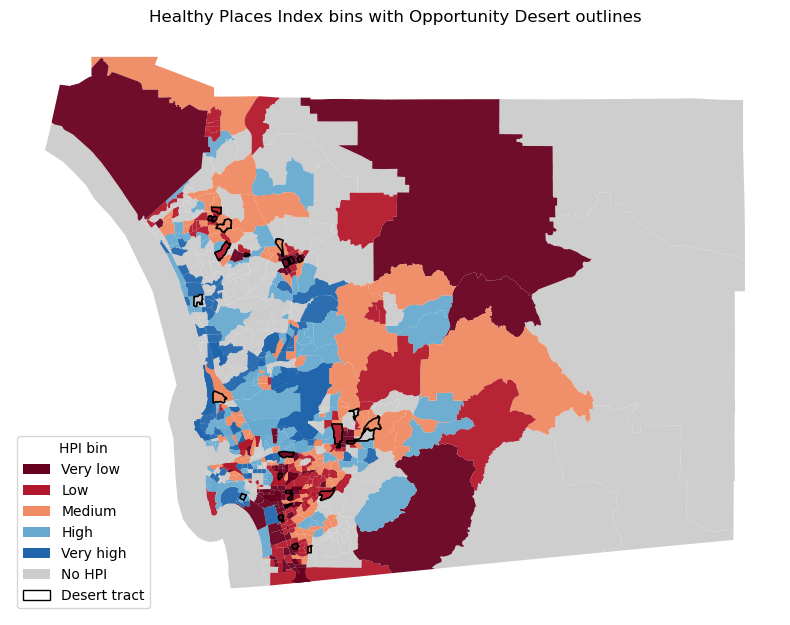

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sd_tracts_plot = sd_tracts_deserts_hpi.to_crs("EPSG:4326")

# Order + colors for bins
bin_order = ["Very low", "Low", "Medium", "High", "Very high", "No HPI"]
bin_colors = {
    "Very low":  "#67001f",   
    "Low":       "#b2182b",
    "Medium":    "#ef8a62",
    "High":      "#67a9cf",
    "Very high": "#2166ac",
    "No HPI":    "#cccccc",
}

# Build a color column
sd_tracts_plot["hpi_color"] = sd_tracts_plot["hpi_bin"].map(bin_colors)

fig, ax = plt.subplots(figsize=(8, 8))

# Plot tracts by HPI bin (categorical colors)
sd_tracts_plot.plot(
    ax=ax,
    color=sd_tracts_plot["hpi_color"],
    edgecolor="none",
    alpha=0.95,
)

# Overlay desert tracts with red outline
deserts = sd_tracts_plot[sd_tracts_plot["desert_flag"] == 1]
if not deserts.empty:
    deserts.boundary.plot(ax=ax, color="black", linewidth=1.2, label="Desert tract")

ax.set_title("Healthy Places Index bins with Opportunity Desert outlines")
ax.set_axis_off()

# Legend for HPI bins
handles = [
    Patch(facecolor=bin_colors[b], edgecolor="none", label=b)
    for b in bin_order if b in sd_tracts_plot["hpi_bin"].unique()
]
if not deserts.empty:
    handles.append(Patch(facecolor="none", edgecolor="black", label="Desert tract"))

ax.legend(
    handles=handles,
    title="HPI bin",
    loc="lower left",
    frameon=True,
)

plt.tight_layout()
plt.show()


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_27226/3416209778.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", frameon=True)


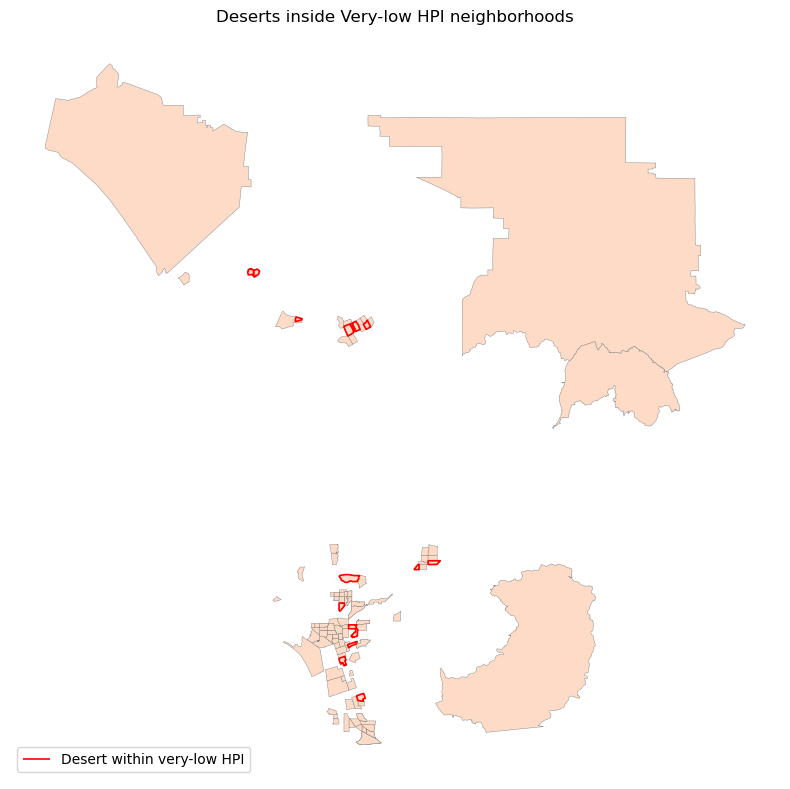

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

# Show only very-low HPI tracts as background
very_low = sd_tracts_plot[sd_tracts_plot["hpi_bin"] == "Very low"]
very_low.plot(ax=ax, color="#fddbc7", edgecolor="grey", linewidth=0.3, label="Very low HPI")

# Among those, highlight deserts
very_low_deserts = very_low[very_low["desert_flag"] == 1]
if not very_low_deserts.empty:
    very_low_deserts.boundary.plot(ax=ax, color="red", linewidth=1.2, label="Desert within very-low HPI")

ax.set_title("Deserts inside Very-low HPI neighborhoods")
ax.set_axis_off()
ax.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_27226/1906369510.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", frameon=True)


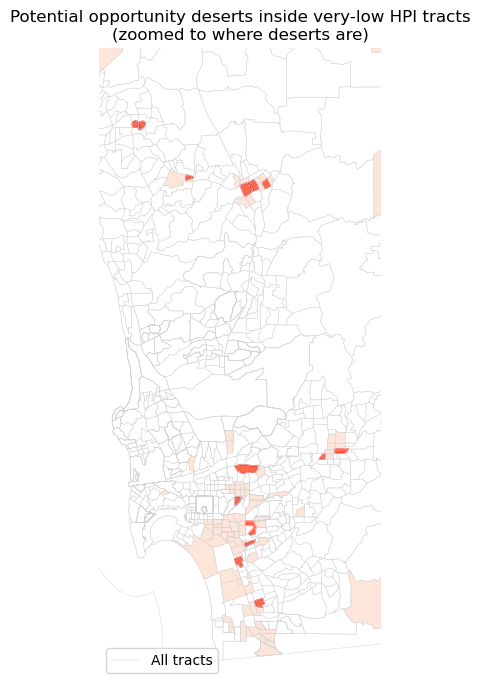

In [46]:
import matplotlib.pyplot as plt

# Work in WGS84
sd_tracts_plot = sd_tracts_deserts_hpi.to_crs("EPSG:4326")

# Very-low HPI tracts
very_low_all = sd_tracts_plot[sd_tracts_plot["hpi_bin"] == "Very low"]

# Deserts within very-low HPI tracts
very_low_deserts = very_low_all[very_low_all["desert_flag"] == 1]

# If no deserts, bail early
if very_low_deserts.empty:
    print("No deserts in very-low HPI tracts.")
else:
    # Compute a tight bounding box around the desert tracts 
    minx, miny, maxx, maxy = very_low_deserts.total_bounds
    pad_x = (maxx - minx) * 0.15
    pad_y = (maxy - miny) * 0.15

    fig, ax = plt.subplots(figsize=(7, 7))

    # All tracts: thin grey outlines for context
    sd_tracts_plot.boundary.plot(
        ax=ax, color="lightgrey", linewidth=0.3, label="All tracts"
    )

    # Very-low HPI tracts: pale fill
    very_low_all.plot(
        ax=ax, color="#fee5d9", edgecolor="none", label="Very-low HPI tract"
    )

    # Deserts within very-low HPI: strong fill + red edge
    very_low_deserts.plot(
        ax=ax, color="#fb6a4a", edgecolor="red", linewidth=0.8,
        label="Desert in very-low HPI"
    )

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    ax.set_title("Potential opportunity deserts inside very-low HPI tracts\n(zoomed to where deserts are)")
    ax.set_axis_off()

    ax.legend(loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()
